In [2]:
import pandas as pd

# Cargamos el dataset de entrenamiento
df = pd.read_csv('data/train.csv')

# Visualizamos las 5 primeras filas para verificar que todo es correcto
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [3]:
# Ver si hay celdas vacías
print("Valores nulos por columna:\n", df.isnull().sum())

# Ver cuántas filas y columnas tenemos
print("\nDimensiones del dataset:", df.shape)

Valores nulos por columna:
 id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

Dimensiones del dataset: (58645, 13)


In [4]:
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64

# Tras analizar la variable objetivo loan_status, se observa que el dataset presenta un desbalanceo significativo (85.7% de clase 0 frente a 14.2% de clase 1). Esto implica que la métrica de Accuracy (precisión global) por sí sola puede ser engañosa. Por lo tanto, en las futuras evaluaciones de los modelos, priorizaré métricas como F1-Score o Recall, que son más robustas ante datasets desbalanceados

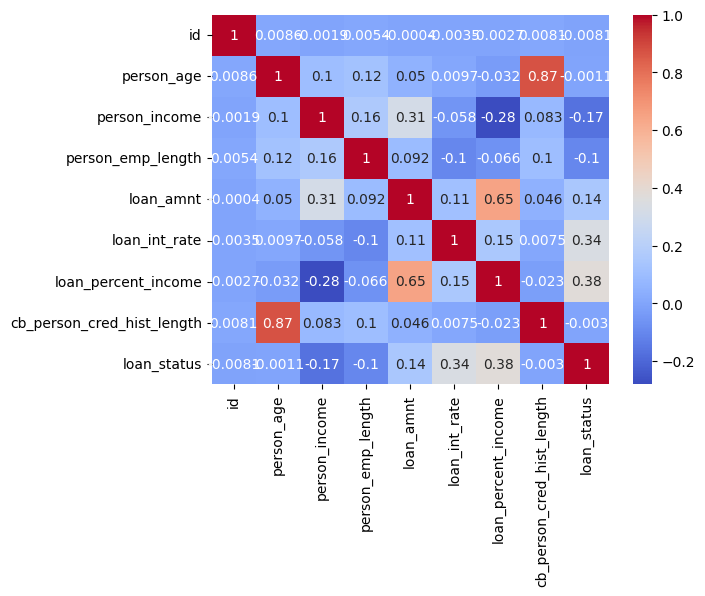

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Solo variables numéricas
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Se observa una correlación positiva moderada (0.38) entre loan_percent_income y loan_status, sugiriendo que el porcentaje de ingresos dedicado al préstamo es un factor relevante para la aprobación. No se han detectado valores nulos que impidan el entrenamiento, por lo que procederé con la fase de preprocesamiento

In [8]:
# Convertimos variables categóricas a numéricas (One-Hot Encoding)
# Esto crea columnas nuevas (ej: person_home_ownership_RENT, person_home_ownership_OWN)
df_encoded = pd.get_dummies(df, drop_first=True)

# Verificamos que ya no quedan letras
print(df_encoded.head())

   id  person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0   0          37          35000                0.0       6000          11.49   
1   1          22          56000                6.0       4000          13.35   
2   2          29          28800                8.0       6000           8.90   
3   3          30          70000               14.0      12000          11.11   
4   4          22          60000                2.0       6000           6.92   

   loan_percent_income  cb_person_cred_hist_length  loan_status  \
0                 0.17                          14            0   
1                 0.07                           2            0   
2                 0.21                          10            0   
3                 0.17                           5            0   
4                 0.10                           3            0   

   person_home_ownership_OTHER  ...  loan_intent_MEDICAL  \
0                        False  ...               

In [9]:
from sklearn.model_selection import train_test_split

# Separamos X (variables de entrada) e y (lo que queremos predecir)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Dividimos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Iniciamos un experimento en MLFlow
mlflow.set_experiment("Loan_Prediction_Experiment")

with mlflow.start_run():
    # 2. Definimos y entrenamos el modelo
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # 3. Predecimos y calculamos métricas
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    
    # 4. Registramos los parámetros y métricas en MLFlow
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_score", f1)
    
    # 5. Guardamos el modelo
    mlflow.sklearn.log_model(model, "random_forest_model")
    
    print(f"Modelo entrenado. Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

2026/04/17 04:12:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/17 04:12:34 INFO mlflow.store.db.utils: Updating database tables
2026/04/17 04:12:35 INFO mlflow.tracking.fluent: Experiment with name 'Loan_Prediction_Experiment' does not exist. Creating a new experiment.
2026/04/17 04:12:35 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
  

Modelo entrenado. Accuracy: 0.9511, F1-Score: 0.8042
